# **Complete repository step-by-step diagnostics. (Simulation Modules)**

Speed values in this repo are km/h, and one simulation tick equals one second.

## **Setup** (using modules from `diagnostic_core.ipynb`)

In [1]:
from typing import Any, Callable, Optional
from IPython.display import Image
from rich import print 

def assert_true(condition: bool, message: str) -> bool:
    if not condition: raise AssertionError(message)
    return True

def validate_call(label: str, expected_valid: bool, func: Callable, *args: Any, **kwargs: Any) -> Optional[Any]:
    try:
        result = func(*args, **kwargs)
    except Exception as exc:
        if expected_valid:
            print(f"[bold red][EXCEPTION] {label}: Expected success but crashed with {type(exc).__name__}({exc})[/bold red]")
        else:
            print(f"[bold cyan][REJECTED] {label}: Safely blocked with {type(exc).__name__}({exc})[/bold cyan]")
        return None
    else:
        if expected_valid:
            print(f"[bold green][VALIDATED] {label}: Executed successfully.[/bold green]")
            return result
        print(f"[bold magenta][FALSE POSITIVE] {label}: Expected rejection but execution succeeded.[/bold magenta]")
        return result


## **Choose below if continue with toy city or iligan**

In [2]:
# =====================================================
# ILIGAN CITY SIMULATION SETUP
# =====================================================

import os
import yaml
from dotenv import load_dotenv
from utils.city_graph import CityGraph
from utils.direct_demand_sampler import DirectDemandSampler, DDMConfig
from utils.route import RouteGenerator
from utils.travel_graph import TravelGraph

load_dotenv()
TOMTOM_API_KEY = os.getenv("TOMTOM_API_KEY")

with open('configs/iligan_configs.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

CACHE_DIR = cfg["global"]["cache_dir"]
os.makedirs(CACHE_DIR, exist_ok=True)

print("[SIM SETUP] Initializing base models...")

city_graph_cfg = cfg["city_graph"]
city = CityGraph(
    bbox=tuple(city_graph_cfg["bbox"]),
    name=city_graph_cfg["name"],
    landmarks=city_graph_cfg.get("landmarks"),
    pbf_path=city_graph_cfg["pbf_path"],
    use_api=False,
    verbose=True,
    cache_dir=CACHE_DIR,
    cache_prefix=city_graph_cfg["cache_prefix"]
)

ddm_params = cfg["ddm"].copy()
ddm_params["cache_dir"] = CACHE_DIR

sampler = DirectDemandSampler(
    city=city,
    config=DDMConfig(**ddm_params),
    verbose=True
)

print("[SIM SETUP] Bypassing route cache. Generating new stochastic routes...")

generator = RouteGenerator(
    city_graph=city,
    sampler=sampler,
    verbose=True
)

tg = TravelGraph(
    cg=city,
    route_generator=generator,
    config=cfg["travel_graph"],
    n_routes=20,
    n_points=5,
)

routes = tg.routes
print("[SIM SETUP] TravelGraph built with fresh routes.")

[SIM SETUP] Initializing base models...

[CITY GRAPH] Loading graph from binary cache.


[CITY GRAPH] Building edges: 100%|██████████| 75761/75761 [00:00<00:00, 201708.21it/s]


[DIRECT DEMAND] Loaded sampler cache from .cache/ddm_models/cdd7bd93ce72e1f98d493dd7bb0b2749.pkl.

[SIM SETUP] Bypassing route cache. Generating new stochastic routes...

[SIM SETUP] TravelGraph built with fresh routes.

In [3]:
# =====================================================
# TOY CITY SIMULATION SETUP
# =====================================================

from utils.route import RouteGenerator
from utils.travel_graph import TravelGraph
from utils.toy_city import toy_setup_from_yaml

print("[SIM SETUP] Initializing toy city models...")

city, sampler, cfg = toy_setup_from_yaml('configs/toy_city_configs.yaml', verbose=True)

print("[SIM SETUP] Bypassing route cache. Generating new stochastic routes...")

generator = RouteGenerator(
    city_graph=city,
    sampler=sampler,
    verbose=True
)

tg = TravelGraph(
    cg=city,
    route_generator=generator,
    config=cfg.get("travel_graph", {}),
    n_routes=20,
    n_points=5,
)

routes = tg.routes
print("[SIM SETUP] TravelGraph built with fresh routes.")

[SIM SETUP] Initializing toy city models...

[TOY CITY] Building 50×50 grid…
CityGraph(ToyCity(50×50)) | Nodes: 2500 | Edges: 9800 (Drivable: 9800) | Landmarks: []
[TOY DDM] Built demand surface over 2500 nodes (2500 drivable) using 11 hotspots.
  · [Downtown Public Market]  weight=15.0  nearest_node_prob=0.00076
  · [University Belt]  weight=12.0  nearest_node_prob=0.00061
  · [North Regional Terminal]  weight=10.0  nearest_node_prob=0.00050
  · [South City Terminal]  weight=10.0  nearest_node_prob=0.00050
  · [Mega Mall Complex]  weight=9.0  nearest_node_prob=0.00045
  · [BPO / Tech Park]  weight=8.0  nearest_node_prob=0.00040
  · [City General Hospital]  weight=7.0  nearest_node_prob=0.00035
  · [Heavy Industrial Zone]  weight=6.0  nearest_node_prob=0.00030
  · [Suburban Residential (East)]  weight=3.0  nearest_node_prob=0.00015
  · [Suburban Residential (Northeast)]  weight=2.0  nearest_node_prob=0.00010
  · [Suburban Residential (Southwest)]  weight=2.5  nearest_node_prob=0.00013
  Demand contrast (max/min prob): 7.5×


[SIM SETUP] Bypassing route cache. Generating new stochastic routes...

[SIM SETUP] TravelGraph built with fresh routes.

## **Jeep System** (in jeep.py and jeep_system.py)

[VALIDATED] Generate demo route: Executed successfully.

[VALIDATED] Spawn jeep on route: Executed successfully.

Target node count for full loop: 122

Successfully traversed all 122 nodes in 2704 ticks.

[VALIDATED] Compile single jeep loop GIF: Executed successfully.

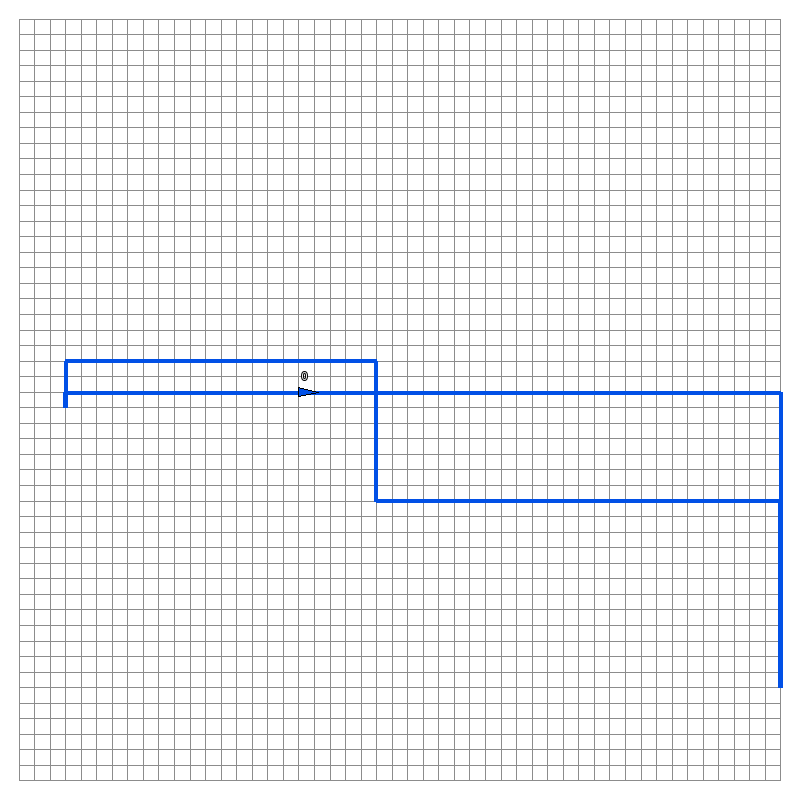

In [4]:
from utils.jeep import Jeep
from utils.visualization import compile_to_gif
from IPython.display import Image as IPyImage, display
from PIL import Image

jeep_speed = cfg["simulation"].get("jeep_speed_kmh", 40.0)

# 1. Generate Route & Initialize Jeep
demo_route = validate_call(
    "Generate demo route",
    True,
    generator.generate,
    n_points=5
)

start_node = demo_route.path[0].start
jeep = validate_call(
    "Spawn jeep on route",
    True,
    Jeep,
    demo_route,
    (start_node.lon, start_node.lat),
    jeep_speed
)

# 2. Track Expected Nodes
expected_node_ids = {edge.start.id for edge in demo_route.path}
traversed_node_ids = set()
print(f"Target node count for full loop: {len(expected_node_ids)}")

# 3. Simulate and Render
context = city.get_bounds()
frames = []
tick = 0
base_map = city.draw(size=800)

while True:
    jeep.update()
    tick += 1
    
    passed_nodes = jeep.nodes_passed_this_frame() or []
    for node, _ in passed_nodes:
        traversed_node_ids.add(node.id)
        
    if tick % 30 == 0:
        frame = demo_route.draw(context, base_map.copy(), width=4)
        frame = jeep.draw(context, frame, radius=12)
        frames.append(frame)

    if traversed_node_ids == expected_node_ids:
        print(f"Successfully traversed all {len(expected_node_ids)} nodes in {tick} ticks.")
        break
    
    if tick > 10000:
        print("[REJECTED] Jeep failed to complete loop within an hour of simulation time.")
        break

gif_bytes = validate_call(
    "Compile single jeep loop GIF",
    True,
    compile_to_gif,
    frames,
    6,
    export_to="utils/.cache/jeep_route_loop.gif"
)
if gif_bytes:
    display(IPyImage(data=gif_bytes, format="gif"))

[VALIDATED] Initialize JeepSystem: Executed successfully.

Running JeepSystem simulation for 300 ticks with 20 jeeps...

Simulation capped at 300 ticks.

[VALIDATED] Compile JeepSystem GIF: Executed successfully.

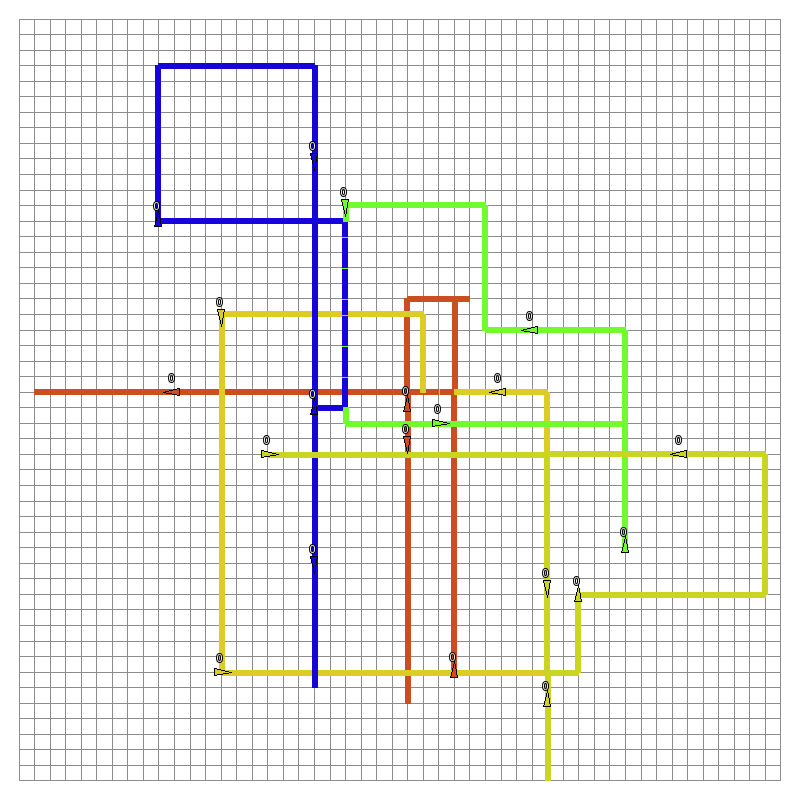

In [5]:
from utils.jeep_system import JeepSystem
from utils.route import RouteSystem
from IPython.display import Image as IPyImage, display

sim_cfg = cfg["simulation"]
num_routes = sim_cfg.get("num_routes", 2)
total_jeeps = sim_cfg.get("total_allocatable_jeeps", 5)
jeep_speed = sim_cfg.get("jeep_speed_kmh", 40.0)
weight_tol = sim_cfg.get("weight_tolerance", 50.0)

# 1. Setup Multiple Routes
rs = RouteSystem()
generated_routes = []
for _ in range(num_routes):
    r = generator.generate(n_points=4)
    rs.add_route(r)
    generated_routes.append(r)

# 2. Spawn Fleet (Even Distribution Fallback)
fleet = []
jeeps_per_route = max(1, total_jeeps // num_routes)

for route in generated_routes:
    for _ in range(jeeps_per_route):
        start = route.path[0].start
        fleet.append(Jeep(route, (start.lon, start.lat), speed=jeep_speed))

system = validate_call(
    "Initialize JeepSystem",
    True,
    JeepSystem,
    jeeps=fleet,
    routes=generated_routes,
    weight_tolerance=weight_tol
)

# 3. Simulate with Tick Cap
system_frames = []
TICK_CAP = 300

context = city.get_bounds()
base_map = city.draw(size=800)
base_map = rs.draw(context, base_map, line_width=6, dash_length=15)

print(f"Running JeepSystem simulation for {TICK_CAP} ticks with {len(fleet)} jeeps...")

for tick in range(TICK_CAP):
    system.update()
    
    if tick % 5 == 0:
        frame = base_map.copy()
        frame = system.draw(context, frame, radius=10)
        system_frames.append(frame)

print(f"Simulation capped at {TICK_CAP} ticks.")

sys_gif_bytes = validate_call(
    "Compile JeepSystem GIF",
    True,
    compile_to_gif,
    system_frames,
    10,
    export_to="utils/.cache/jeep_system_demo.gif"
)
if sys_gif_bytes:
    display(IPyImage(data=sys_gif_bytes, format="gif"))

## **Passenger Generator** (in passenger.py and passenger_generator.py)

In [6]:
from utils.passenger import Passenger
from utils.travel_graph import TravelGraph
from IPython.display import Image as IPyImage, display

pax_speed = cfg["simulation"].get("passenger_speed_kmh", 5.0)

print("[TEST SETUP] Building localized TravelGraph (3 routes) to force edge cases...")
test_tg = TravelGraph(
    cg=city,
    route_generator=generator,
    config=cfg["travel_graph"],
    n_routes=3,
    n_points=5,
)

case_di = None
case_ri = None
case_tr = None

print("[TEST SETUP] Sampling journeys...")
attempts = 0
while not (case_di and case_ri and case_tr):
    attempts += 1
    origin = sampler.get_point()
    dest = sampler.get_point()
    journey = test_tg.findShortestJourney(origin, dest)

    if not journey:
        continue

    prefixes = set(e.id[:2] for e in journey)

    if "DI" in prefixes and not case_di:
        case_di = journey
        print(f" -> Found Direct/Walk-Only (DI) case in {attempts} attempts.")
    elif "RI" in prefixes and "TR" not in prefixes and not case_ri:
        case_ri = journey
        print(f" -> Found Single Ride (RI) case in {attempts} attempts.")
    elif "TR" in prefixes and not case_tr:
        case_tr = journey
        print(f" -> Found Transfer (TR) case in {attempts} attempts.")

    if attempts > 5000:
        print("[WARNING] Failsafe triggered. Could not find all edge cases within 5000 attempts.")
        break

class MockJeep:
    def __init__(self, pos):
        self.curr_pos = pos

def simulate_passenger_lifecycle(journey_path: list, label: str, speed_val: float) -> list[str]:
    test_passenger = Passenger(
        start_pos=(journey_path[0].start.lon, journey_path[0].start.lat),
        journey=journey_path,
        speed=speed_val
    )
    
    tick = 0
    state_history = []
    ride_ticks = 0
    target_node = None

    print(f"\n[SIMULATING] {label} | {len(journey_path)} edges")

    while test_passenger.state != Passenger.DONE:
        test_passenger.update()
        tick += 1
        
        if not state_history or state_history[-1] != test_passenger.state:
            state_history.append(test_passenger.state)
            current_edge_id = test_passenger.journey[test_passenger._edge_idx].id if test_passenger._edge_idx < len(test_passenger.journey) else "N/A"
            print(f"  [Tick {tick:03d}] State: {test_passenger.state:<8} | Active Edge: {current_edge_id}")
        
        if test_passenger.state == Passenger.WAITING and test_passenger.wait_ticks > 5:
            target_node = test_passenger.get_target_alight_node()
            test_passenger.current_jeep = MockJeep((test_passenger.curr_lon, test_passenger.curr_lat))
            test_passenger.state = Passenger.RIDING
            test_passenger.wait_ticks = 0
            ride_ticks = 0
            
        elif test_passenger.state == Passenger.RIDING:
            ride_ticks += 1
            if ride_ticks > 5:
                if target_node:
                    test_passenger.current_jeep.curr_pos = (target_node.lon, target_node.lat)
                    test_passenger.curr_lat = target_node.lat
                    test_passenger.curr_lon = target_node.lon
                test_passenger.complete_ride()
                test_passenger.current_jeep = None
                test_passenger.state = Passenger.WALKING
                
        if tick > 7200:
            raise RuntimeError(f"{label} failed to complete within 2 simulated hours.")

    return state_history

test_cases = [
    ("Direct Journey", case_di),
    ("Single Ride Journey", case_ri),
    ("Transfer Journey", case_tr)
]

for name, j in test_cases:
    if not j:
        print(f"[REJECTED] Missing journey for {name}. Skipping.")
        continue

    history = validate_call(
        f"Simulate {name}",
        True,
        simulate_passenger_lifecycle,
        j, name, pax_speed
    )

    if history:
        validate_call(
            f"{name} Lifecycle validation",
            True,
            assert_true,
            Passenger.DONE in history,
            f"{name} did not reach DONE state."
        )

[TEST SETUP] Building localized TravelGraph (3 routes) to force edge cases...

[TEST SETUP] Sampling journeys...

-> Found Single Ride (RI) case in 1 attempts.

-> Found Direct/Walk-Only (DI) case in 3 attempts.

-> Found Transfer (TR) case in 263 attempts.

...

[Tick 730] State: 2        | Active Edge: RI_R1_00296

[Tick 736] State: 0        | Active Edge: EW02724

[Tick 825] State: 3        | Active Edge: N/A

[VALIDATED] Simulate Transfer Journey: Executed successfully.

[VALIDATED] Transfer Journey Lifecycle validation: Executed successfully.

[VALIDATED] Initialize PassengerGenerator: Executed successfully.

Running PassengerGenerator simulation for 13 visual ticks...

Simulation complete. Metric summary:

- Currently Active: 15

- Successfully Archived (DONE): 0

- Total Generated: 15

[VALIDATED] Compile PassengerGenerator GIF: Executed successfully.

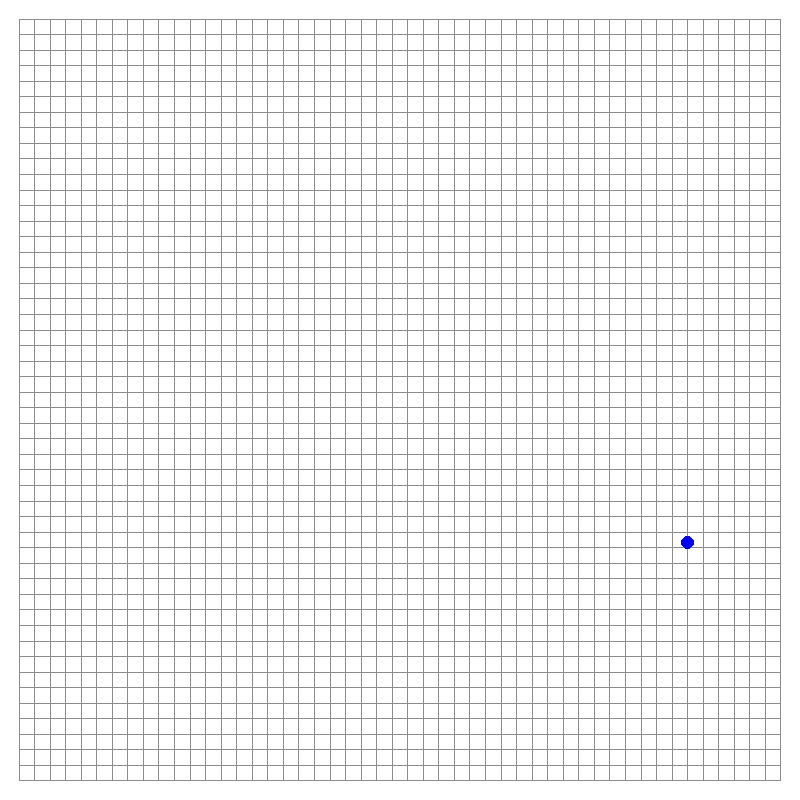

In [7]:
from utils.passenger_generator import PassengerGenerator

sim_cfg = cfg["simulation"]
pax_speed = sim_cfg.get("passenger_speed_kmh", 5.0)
spawn_rate = sim_cfg.get("spawn_rate_per_hour", 40.0)
spawn_std = sim_cfg.get("spawn_stdev", 5.0)
seconds_per_tick = sim_cfg.get("seconds_per_tick", 1)

pg = validate_call(
    "Initialize PassengerGenerator",
    True,
    PassengerGenerator,
    tg=tg,
    sampler=sampler,
    rate_per_hour=spawn_rate, 
    stdev=spawn_std,
    speed=pax_speed,
    seconds_per_tick=seconds_per_tick
)

# Adjust visual ticks to account for the scalar
TARGET_VISUAL_SECONDS = 400
VISUAL_TICKS = int(TARGET_VISUAL_SECONDS / seconds_per_tick)
pg_frames = []

context = city.get_bounds()
base_map = city.draw(size=800)

print(f"Running PassengerGenerator simulation for {VISUAL_TICKS} visual ticks...")

for tick in range(VISUAL_TICKS):
    pg.update()
    
    frame = base_map.copy()
    for p in pg.passengers:
        frame = p.draw(context, frame, size=6)
    pg_frames.append(frame)

print("Simulation complete. Metric summary:")
print(f" - Currently Active: {len(pg.passengers)}")
print(f" - Successfully Archived (DONE): {len(pg.archived_passengers)}")
print(f" - Total Generated: {len(pg.get_all_generated_journeys())}")

pg_gif_bytes = validate_call(
    "Compile PassengerGenerator GIF",
    True,
    compile_to_gif,
    pg_frames,
    8,
    export_to="utils/.cache/passenger_generator_demo.gif"
)
if pg_gif_bytes:
    display(IPyImage(data=pg_gif_bytes, format="gif"))

## **Simulation** (in simulation.py, using the new live visualizer from visualization.py)

[VALIDATED] Assemble Simulation Architecture: Executed successfully.

[DIAGNOSTIC] Running 200 headless ticks for warmup...

[VALIDATED] Jeep Capacity Constraint: Executed successfully.

[VALIDATED] Passenger Boarding Logic: Executed successfully.

[DIAGNOSTIC] Peak Occupancy: 14/16

[DIAGNOSTIC] Completed Journeys: 35

[DIAGNOSTIC] Currently Riding: 117

[DIAGNOSTIC] Recording 800 visual ticks -> ~53 GIF frames (1 per 15 ticks)...

[DIAGNOSTIC] Captured 54 frames.

[VALIDATED] Compile Simulation GIF: Executed successfully.

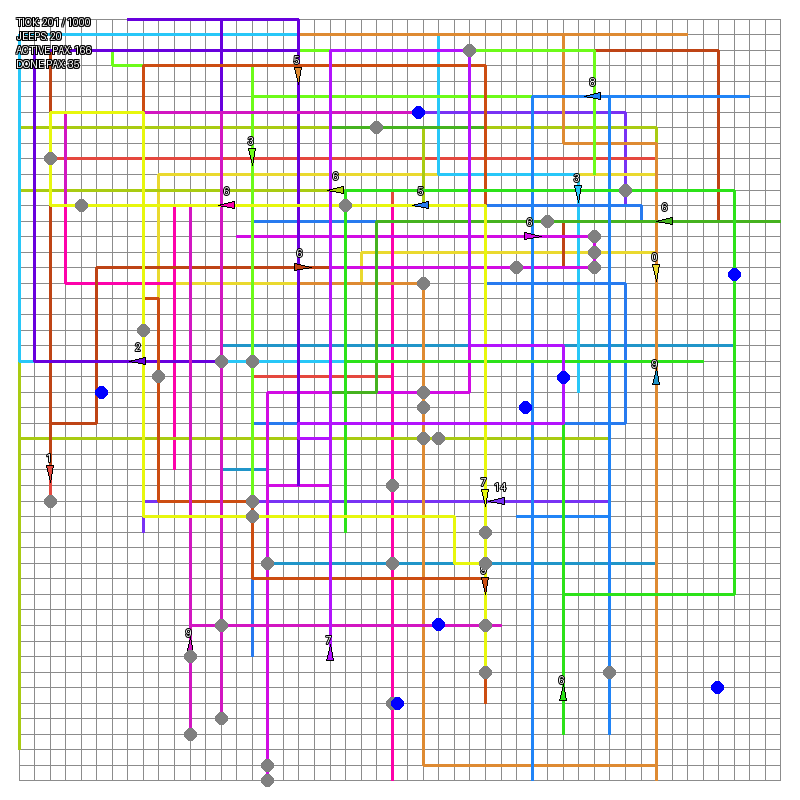

In [8]:
import os
from IPython.display import Image as IPyImage, display

from utils.jeep import Jeep
from utils.jeep_system import JeepSystem
from utils.passenger import Passenger
from utils.passenger_generator import PassengerGenerator
from utils.simulation import Simulation
from utils.visualization import compile_to_gif

sim_cfg = cfg.get("simulation", {})
jeeps = []
total_jeeps = sim_cfg.get("total_allocatable_jeeps", 25)
jeep_speed = sim_cfg.get("jeep_speed_kmh", 40.0) 
jeep_capacity = sim_cfg.get("jeep_capacity", 16)
weight_tol = sim_cfg.get("weight_tolerance", 50.0)
seconds_per_tick = sim_cfg.get("seconds_per_tick", 1)

jeeps_per_route = max(1, total_jeeps // len(routes))

for route in routes:
    for _ in range(jeeps_per_route):
        start_coord = (route.path[0].start.lon, route.path[0].start.lat)
        jeeps.append(Jeep(route, curr_pos=start_coord, speed=jeep_speed, max_capacity=jeep_capacity, seconds_per_tick=seconds_per_tick))
        
jeep_system = JeepSystem(
    jeeps=jeeps, 
    routes=routes, 
    weight_tolerance=weight_tol,
    equidistant_spawn=True
)

passenger_generator = PassengerGenerator(
    tg=tg,
    sampler=sampler,
    rate_per_hour=sim_cfg.get("spawn_rate_per_hour", 40.0),
    stdev=sim_cfg.get("spawn_stdev", 5.0),
    speed=sim_cfg.get("passenger_speed_kmh", 5.0),
    seconds_per_tick=seconds_per_tick
)

sim = validate_call(
    "Assemble Simulation Architecture",
    True,
    Simulation,
    city_query="Toy City",
    bounds=city.get_bounds(),
    jeep_system=jeep_system,
    passenger_generator=passenger_generator,
    max_ticks=sim_cfg.get("num_ticks", 300),
    beta_penalty=cfg.get("BETA_PENALTY", 2.0),
    alpha_std_penalty=cfg.get("ALPHA_STD_PENALTY", 0.5),
    config=cfg
)

TOTAL_TICKS = sim.max_ticks
HEADLESS_TICKS = max(1, int(TOTAL_TICKS * 0.2))
VISUAL_TICKS = TOTAL_TICKS - HEADLESS_TICKS
max_occupancy_recorded = 0

print(f"[DIAGNOSTIC] Running {HEADLESS_TICKS} headless ticks for warmup...")

for _ in range(HEADLESS_TICKS):
    sim.update()
    
    current_max_occ = max([getattr(j, 'curr_passenger_count', 0) for j in sim.jeep_system.jeeps] + [0])
    if current_max_occ > max_occupancy_recorded:
        max_occupancy_recorded = current_max_occ
        
validate_call(
    "Jeep Capacity Constraint", 
    True, 
    assert_true, 
    max_occupancy_recorded <= jeep_capacity, 
    f"Capacity breach: Recorded {max_occupancy_recorded}, Limit {jeep_capacity}"
)

pax_riding = sum(1 for p in sim.passenger_generator.passengers if p.state == Passenger.RIDING)
pax_done = len(sim.passenger_generator.archived_passengers)

validate_call(
    "Passenger Boarding Logic",
    True,
    assert_true,
    pax_riding > 0 or pax_done > 0,
    "No passengers successfully boarded a jeep during the timeframe."
)

print(f"[DIAGNOSTIC] Peak Occupancy: {max_occupancy_recorded}/{jeep_capacity}")
print(f"[DIAGNOSTIC] Completed Journeys: {pax_done}")
print(f"[DIAGNOSTIC] Currently Riding: {pax_riding}")

# FIX 1: get_bounds() already returns ((tl_lon, tl_lat), (br_lon, br_lat)).
# Use it directly instead of destructuring and reconstructing the same value.
context_bounds = city.get_bounds()

# FIX 2: Capture route.draw() return value so base_map is reliably updated.
# (route.draw mutates in-place via ImageDraw, but discarding the return value
# is fragile and causes stacked routes on notebook re-runs.)
base_map = city.draw(size=800)
for route in routes:
    base_map = route.draw(context=context_bounds, image=base_map, width=3)

sim_frames = []

# FIX 3: Subsample frames — only record 1 frame every FRAME_EVERY_N_TICKS ticks.
#
# At 1 tick = seconds_per_tick sim-seconds, entities move only ~1-11 m/tick
# at city scale (5 km/h walking -> ~1.4 m/tick, 40 km/h jeep -> ~11 m/tick).
# An 800px map covering hundreds of meters means movement is often sub-pixel,
# making the GIF appear completely frozen when every tick is a frame.
# Subsampling ensures visible inter-frame displacement.
FRAME_EVERY_N_TICKS = max(1, sim_cfg.get("frame_every_n_ticks", 15))
expected_frames = VISUAL_TICKS // FRAME_EVERY_N_TICKS
print(f"[DIAGNOSTIC] Recording {VISUAL_TICKS} visual ticks -> ~{expected_frames} GIF frames (1 per {FRAME_EVERY_N_TICKS} ticks)...")

for tick in range(VISUAL_TICKS):
    sim.update()
    
    if tick % FRAME_EVERY_N_TICKS == 0:
        frame = base_map.copy()
        frame = sim.draw(context_bounds, frame, draw_jeeps=True, draw_passengers=True)
        frame = sim.draw_dashboard(frame)
        sim_frames.append(frame)

print(f"[DIAGNOSTIC] Captured {len(sim_frames)} frames.")
os.makedirs("utils/.cache", exist_ok=True)

gif_bytes = validate_call(
    "Compile Simulation GIF",
    True,
    compile_to_gif,
    sim_frames,
    10,
    export_to="utils/.cache/simulation_diagnostic.gif"
)

if gif_bytes:
    display(IPyImage(data=gif_bytes, format="gif"))


In [9]:
# headless test

import time
from tqdm.auto import tqdm

print("[BENCHMARK] Assembling clean simulation instance...")

benchmark_jeeps = []
for route in routes:
    for _ in range(jeeps_per_route):
        start_coord = (route.path[0].start.lon, route.path[0].start.lat)
        benchmark_jeeps.append(Jeep(route, curr_pos=start_coord, speed=jeep_speed, max_capacity=jeep_capacity, seconds_per_tick=seconds_per_tick))

benchmark_js = JeepSystem(
    jeeps=benchmark_jeeps,
    routes=routes,
    weight_tolerance=weight_tol,
    equidistant_spawn=True
)

benchmark_pg = PassengerGenerator(
    tg=tg,
    sampler=sampler,
    rate_per_hour=sim_cfg.get("spawn_rate_per_hour", 40.0),
    stdev=sim_cfg.get("spawn_stdev", 5.0),
    speed=sim_cfg.get("passenger_speed_kmh", 5.0),
    seconds_per_tick=seconds_per_tick
)

sim_benchmark = Simulation(
    city_query="Iligan",
    bounds=city.get_bounds(),
    jeep_system=benchmark_js,
    passenger_generator=benchmark_pg,
    max_ticks=sim_cfg.get("num_ticks", 3600),
    beta_penalty=cfg.get("BETA_PENALTY", 2.0),
    alpha_std_penalty=cfg.get("ALPHA_STD_PENALTY", 0.5),
    config=cfg
)

def run_with_progress():
    pbar = tqdm(total=sim_benchmark.max_ticks, desc="Headless Simulation")
    original_update = sim_benchmark.update
    
    def wrapped_update():
        original_update()
        pbar.update(1)
        
    sim_benchmark.update = wrapped_update
    
    try:
        # Calls the original run which now uses wrapped_update
        return sim_benchmark.run()
    finally:
        pbar.close()

print(f"[BENCHMARK] Executing {sim_benchmark.max_ticks} headless ticks...")

start_time = time.perf_counter()
result = validate_call("Run Headless Benchmark", True, run_with_progress)
end_time = time.perf_counter()

if result:
    elapsed = end_time - start_time
    print(f"[BENCHMARK] Execution completed in {elapsed:.4f} seconds.")
    print(f"[BENCHMARK] Fitness Score: {result.fitness_score:.2f}")
    print(f"[BENCHMARK] Processed {result.metrics['completed_count']} completed passenger journeys.")

[BENCHMARK] Assembling clean simulation instance...

[BENCHMARK] Executing 1000 headless ticks...

Headless Simulation:   0%|          | 0/1000 [00:00<?, ?it/s]

[VALIDATED] Run Headless Benchmark: Executed successfully.

[BENCHMARK] Execution completed in 5.0193 seconds.

[BENCHMARK] Fitness Score: 13561332.13

[BENCHMARK] Processed 191 completed passenger journeys.